#### Outline
- [Import Libraries](#Import-Libraries)
- [Data Understanding and Exploratory](#Data-Understanding-and-Exploratory)
- [Data Cleaning, Preprocessing & Feature Engineering](#Data-Cleaning,-Preprocessing-&-Feature-Engineering)
- [Model Development](#Model-Development)
- [Model Evaluation](#Model-Evaluation)
- [Model Deployment](#Model-Deployment)
- [Business Interpretation](#Business-Interpretation)
- [Project Conclusion](#Project-Conclusion)


#### Import Libraries

In [1]:
# GLOBAL DIGITAL PAYMENT FRAUD DETECTION
# Step 1: Import Libraries


# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


# Handle Imbalanced Data
#from imblearn.over_sampling import SMOTE

# Save Model
import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Please Note, since it is a a Global Digital Payment Fraud Detection project, our target 
# variable is is_fraud. Thus it is a binary classification problem, not regression.

####  Data Understanding and Exploratory

2.1 Load Dataset

In [2]:
# Load Data
df = pd.read_csv("nova_pay_transactions.csv")

In [3]:
print(df.shape)
df.head()


(10200, 26)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [4]:
df.tail()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
10195,a5c6391d-4763-4ed6-a5ef-80b744cf71b2,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-11-25 16:25:46.468549+00:00,US,USD,GBP,mobile,127.91,127.91,2.97,0.800000,9171f520-2708-4197-8ca1-654eac5b6a52,False,194.98.205.238,US,False,0.315,standard,1018,0.934,0,0.087,0,0,0.0,0
10196,35c133e7-7279-4d24-ac0e-967675f2c2a0,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2023-01-13 16:50:48.468549+00:00,US,USD,CNY,ATM,286.59,286.59,5.12,7.142857,bb7ba592-6225-4d47-a026-bc487b59aa8a,False,141.199.241.52,US,False,0.383,enhanced,257,0.894,0,0.257,0,0,0.0,0
10197,6263d697-0900-440c-99d7-b4be90e733b5,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-07-02 11:33:48.468549+00:00,US,USD,USD,mobile,230.09,230.09,4.01,1.000000,0b1e2b5a-73ef-4a73-b61e-9ddc6ff092e6,False,90.83.16.134,US,False,0.244,enhanced,367,0.939,0,0.176,0,0,0.0,0
10198,883403f5-fd2f-4b39-824e-9710485a983e,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-01-01 02:40:14.468549+00:00,UK,GBP,PHP,mobile,-168.96,211.20,9999.99,73.529412,e70db499-19e1-4927-b04f-3ebfcf62e33c,False,94.169.104.121,UK,False,1.200,standard,4,-0.100,0,0.407,-1,0,0.0,0
10199,f122f3ba-42fc-4018-85d1-57e71b525691,a07adabc-9a06-4e28-b1d6-83b128f4219a,2023-07-28 19:12:42.468549+00:00,US,USD,EUR,mobile,65.43,65.43,2.11,0.925926,0c89f91c-6b15-49f6-8a66-d0066737e461,True,132.195.29.204,US,False,0.182,standard,859,0.810,0,0.363,0,0,0.0,0


3 Data Inspection

In [5]:
# 3.1 Get dataset general information
#

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10200 non-null  str    
 1   customer_id                10200 non-null  str    
 2   timestamp                  10171 non-null  str    
 3   home_country               10200 non-null  str    
 4   source_currency            10200 non-null  str    
 5   dest_currency              10200 non-null  str    
 6   channel                    10200 non-null  str    
 7   amount_src                 10200 non-null  str    
 8   amount_usd                 9895 non-null   float64
 9   fee                        9905 non-null   float64
 10  exchange_rate_src_to_dest  10200 non-null  float64
 11  device_id                  10200 non-null  str    
 12  new_device                 10200 non-null  bool   
 13  ip_address                 9895 non-null   str    
 14  i

In [6]:
# 3.2 Get missing values

df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [7]:
# 3.3  Check percentage Missing of any Missing Varables

# Non torelance limit starts from 5% - 30%
# torelance limit is less than 2% - 5%


missing_percent = (df.isnull().sum()/len(df))*100

missing_only = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_only)

amount_usd            2.990196
ip_address            2.990196
ip_country            2.950980
kyc_tier              2.941176
fee                   2.892157
device_trust_score    2.892157
timestamp             0.284314
dtype: float64


4. Duplicate Records

In [8]:
# Check for Duplicates

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 200


In [9]:
# 4.1 Drop duplicates based on transaction_id, keeping the first occurrence
df_cleaned = df.drop_duplicates(subset=['transaction_id'], keep='first')

# Reset the index cleanly
df_cleaned = df_cleaned.reset_index(drop=True)

# Verify that it worked (it should now display 1s instead of 2s)
print(df_cleaned['transaction_id'].value_counts().head())

transaction_id
fee8542d-8ee6-4b0d-9671-c294dd08ed26    1
bfdb9fc1-27fe-4a85-b043-4d813d679259    1
fc855034-3ea5-4993-9afa-b511d93fe5e8    1
2cf8c08e-42ec-444d-a755-34b9a2a0a4ca    1
d907a74d-b426-438d-97eb-dbe911aca91c    1
Name: count, dtype: int64


In [10]:
df_cleaned.head(10)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
5,ec17d6f2-6505-4de9-910f-0de3ac3bbc23,4cfe5cbc-d677-49bc-8739-b1d05f351250,2022-10-04 12:09:59.468549+00:00,US,USD,GBP,mobile,526.9,526.90,8.75,0.800000,209e3bb0-50ea-49b7-a681-036adf7b1251,False,191.142.136.198,US,False,0.094,low,616,0.702,0,0.361,0,0,0.00,0
6,2d8efe37-33ea-40de-9881-e553e3f2f8ce,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-04 12:37:41.468549+00:00,CA,CAD,GBP,mobile,149.24,110.44,2.33,0.592000,cd539961-17ad-4f6b-94ae-8080423af5e3,False,106.34.98.71,CA,False,0.299,standard,947,0.625,0,0.268,0,0,0.00,0
7,4d311532-ee0b-4985-b996-63e11a7144d3,4dfeffe2-94ed-4fc3-b5bc-89c6f1e86dab,2022-10-04 16:27:44.468549+00:00,CA,CAD,INR,web,276.51,204.62,5.59,61.666667,96468499-b7b2-4273-a946-dbf2cb7dc95a,False,32.170.54.208,CA,False,0.087,standard,1041,0.867,0,0.245,0,1,0.12,0
8,db5bdea7-0701-4c07-9efa-815fa6ca9ede,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-04 21:00:36.468549+00:00,US,USD,EUR,mobile,99.52,99.52,2.41,0.925926,3c27e832-cb50-4fc5-b782-ec97f6a5d50c,False,109.242.237.91,US,False,0.182,enhanced,367,0.939,0,0.176,0,0,0.00,0
9,d74c81c0-bf5d-4184-8ce2-27fb753cb1c6,f7531a78-8bbe-4a85-b1e8-a0650edddc72,2022-10-04 21:20:42.468549+00:00,US,USD,PHP,web,302.55,302.55,5.26,58.823529,3df8c73d-b716-4a6e-8172-d2b7359b60b2,False,103.237.21.29,US,False,0.413,standard,1016,0.944,0,0.247,0,0,0.10,1


In [11]:
# 4.2 check the shape of the dataset, how many rows and columns are removing deplicated rows
df_cleaned.shape

(10000, 26)

In [12]:
# 4.3 Get the Descriptive Statitics of the dataset
df_cleaned.describe().round(2)

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,9700.00,9710.00,10000.00,10000.00,10000.00,9710.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,409.80,109.90,150.64,0.36,421.90,0.68,0.00,0.24,0.13,0.23,0.04,0.02
std,1425.75,1009.14,359.83,0.23,339.33,0.25,0.05,0.10,0.95,0.98,0.08,0.14
min,7.23,-1.00,0.59,0.00,4.00,-0.10,0.00,0.00,-1.00,0.00,0.00,0.00
25%,88.18,2.31,1.00,0.20,257.00,0.52,0.00,0.17,0.00,0.00,0.00,0.00
50%,151.73,3.33,7.14,0.31,298.00,0.78,0.00,0.22,0.00,0.00,0.00,0.00
75%,267.64,5.04,61.67,0.44,718.00,0.92,0.00,0.33,0.00,0.00,0.00,0.00
max,12498.57,9999.99,1388.89,1.20,1092.00,0.97,2.00,0.55,8.00,9.00,0.25,1.00


 Exploratory Data Analysis

In [13]:
# 1.1  Possible Fraud Distribution

# It is a binary classification target of detecting fraud

# 0 = Legitimate (non-fraudulent) transaction
# 1 = Fraudulent transaction
# We have 9805 Legitimate Transaction
# There is also suspected 195 Fraudulent Transaction

df_cleaned['is_fraud'].value_counts()

is_fraud
0    9805
1     195
Name: count, dtype: int64

In [14]:
# 1.2  Percentage Fraud
# We have 98.05% Legitimate Transaction
# We also have 1.95% suspected Fraudulent Transaction

fraud_percentage = (
    df_cleaned['is_fraud']
      .value_counts(normalize=True)
      *100
)

fraud_percentage

is_fraud
0    98.05
1     1.95
Name: proportion, dtype: float64

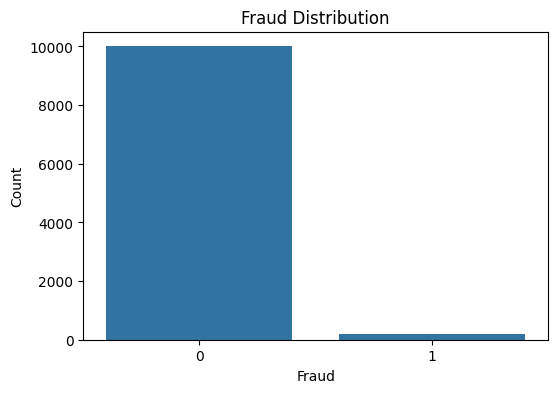

In [15]:
# 1.3 Fraud Count Plot

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='is_fraud'
)

plt.title("Fraud Distribution")

plt.xlabel("Fraud")

plt.ylabel("Count")

plt.show()

In [16]:
# This helps us to understand how the numeric data is spread out across the range of the dataset values

numerical_columns = df_cleaned.select_dtypes(include=np.number).columns

numerical_columns

Index(['amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score',
       'account_age_days', 'device_trust_score', 'chargeback_history_count',
       'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h',
       'corridor_risk', 'is_fraud'],
      dtype='str')

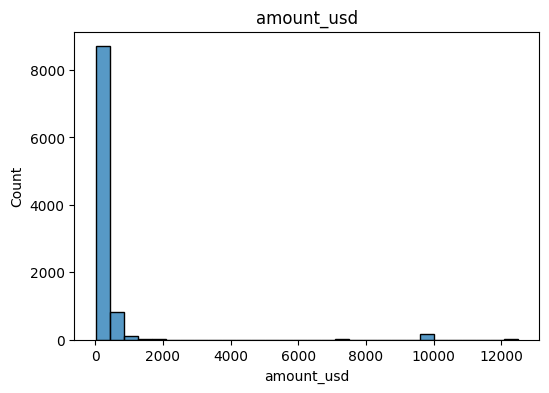

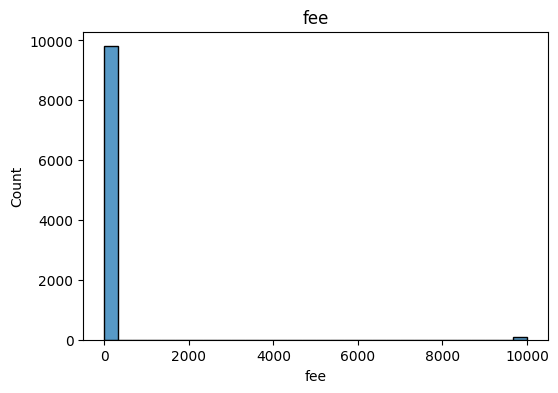

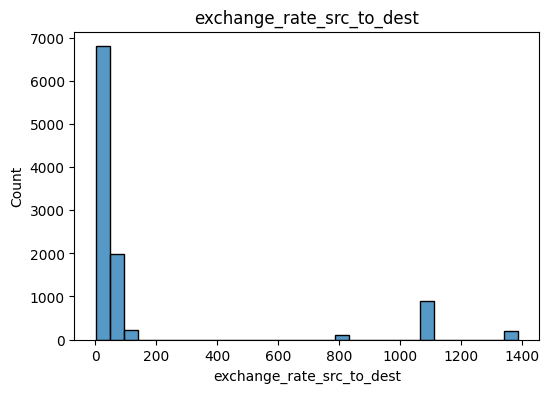

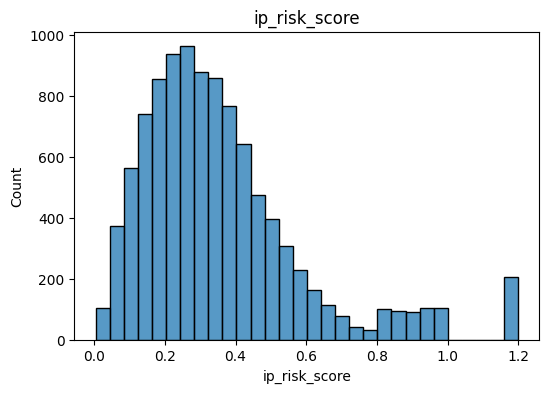

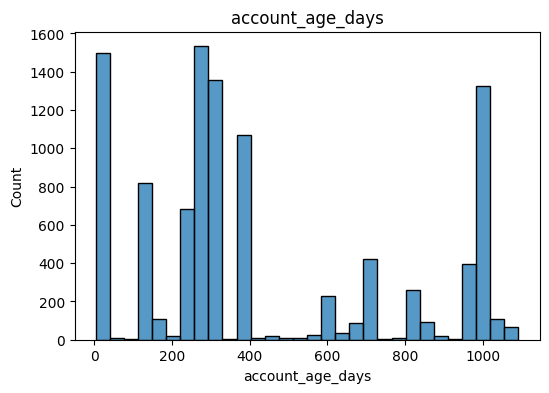

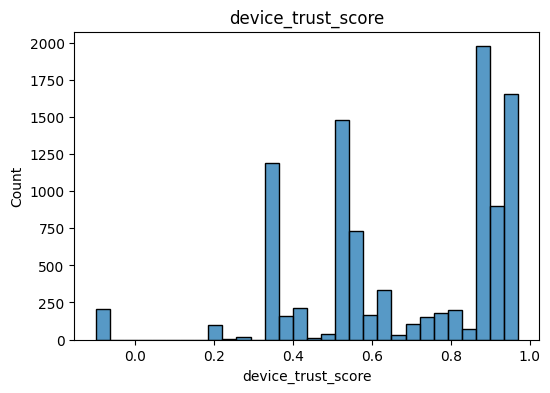

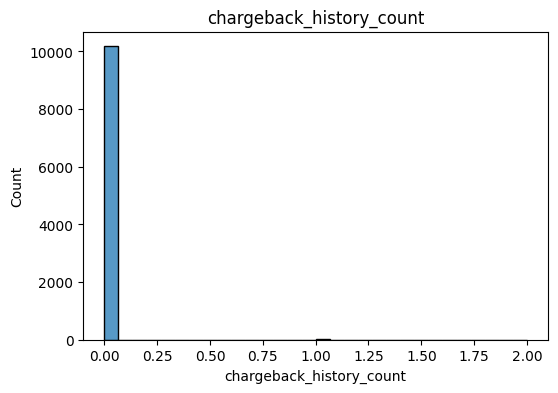

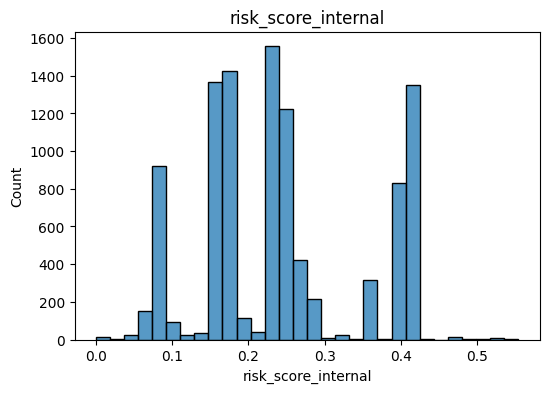

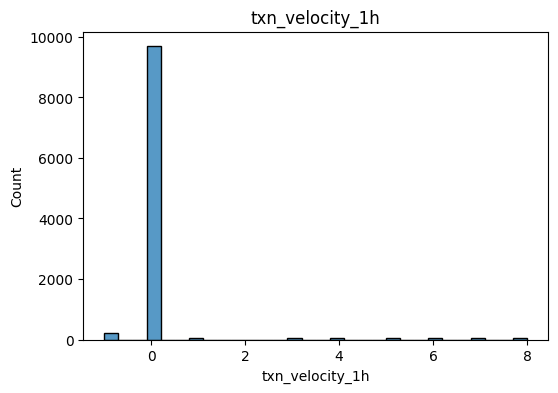

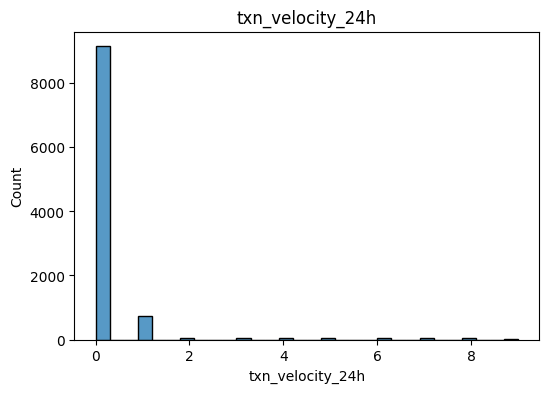

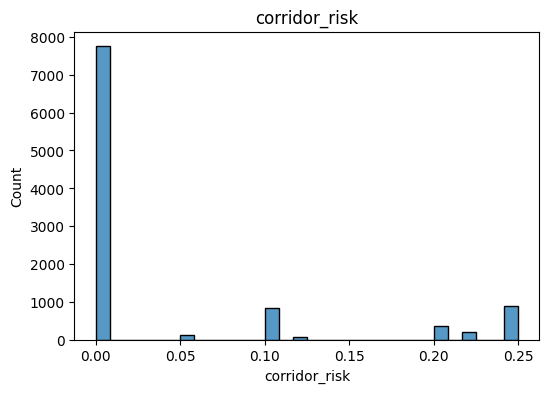

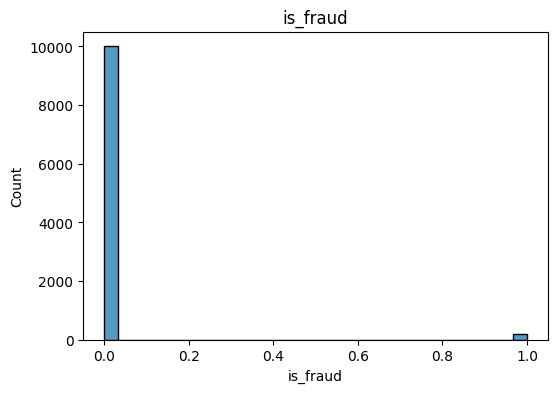

In [17]:

# 1.4 This Code is used to visualize the distribution of each numerical variable in your dataset before Cleaning 
# It helps to understand the characteristics of the data before cleaning, feature engineering, and model building.


for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], bins=30)

    plt.title(col)

    plt.show()

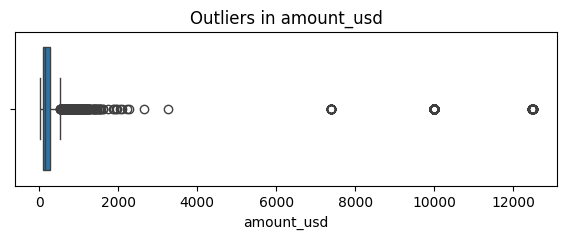

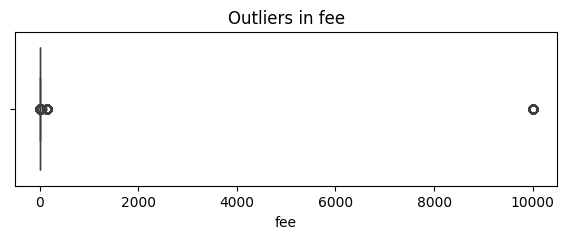

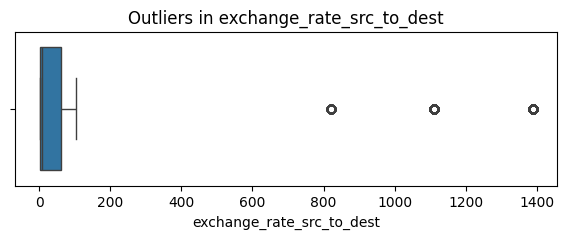

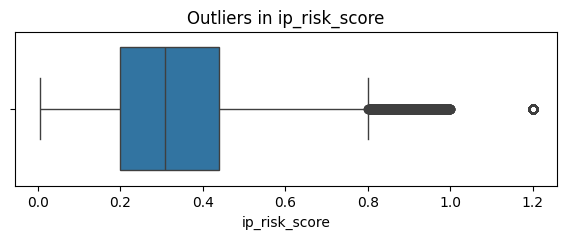

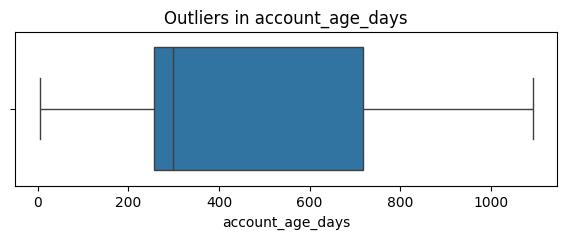

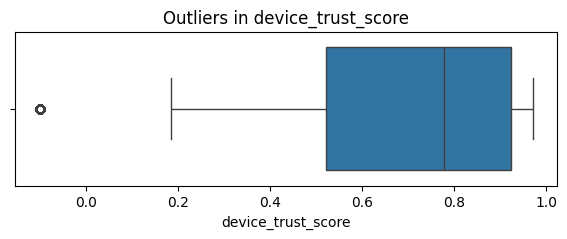

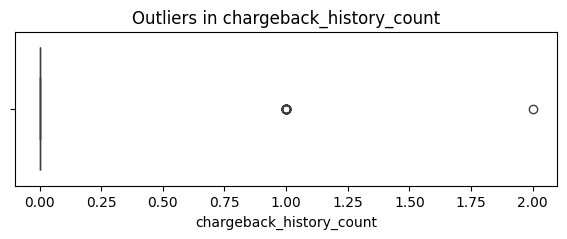

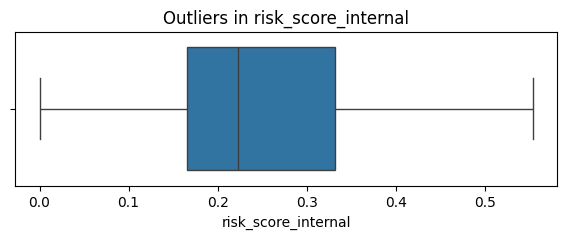

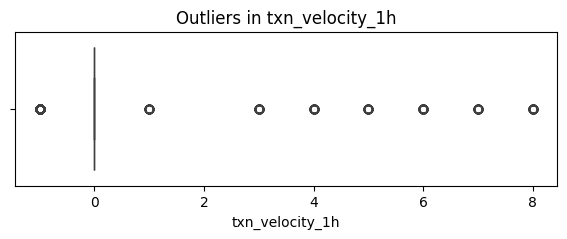

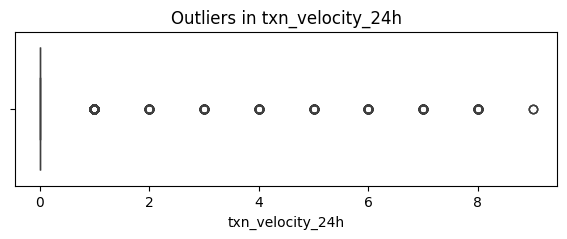

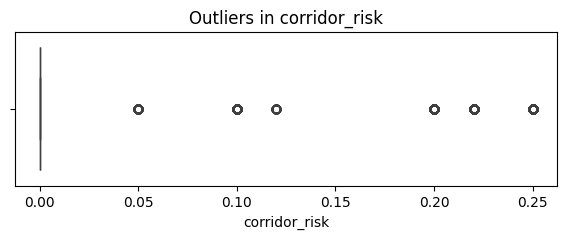

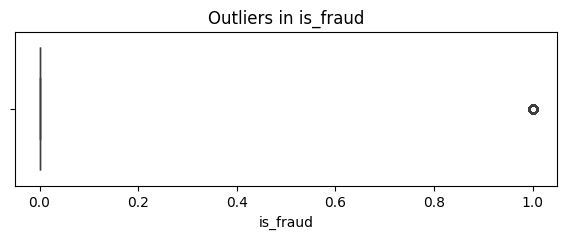

In [18]:
# 1.5 Detect Outliers. This result is before the cleaning and preprocessing stage



for col in numerical_columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[col])

    plt.title(f"Outliers in {col}")

    plt.show()

In [19]:
# 1.6 Check for skewness this result is before the cleaning and preprocessing stage

# Skewness nterpretation:

# Between -0.5 and 0.5 → Approximately symmetric
# Between 0.5 and 1 or -0.5 and -1 → Moderately skewed
# Greater than 1 or less than -1 → Highly skewed

skewness = df_cleaned[numerical_columns].skew()

skewness.sort_values(ascending=False)

chargeback_history_count     21.531949
fee                           9.696284
is_fraud                      6.951002
amount_usd                    6.753566
txn_velocity_1h               6.371586
txn_velocity_24h              5.843971
exchange_rate_src_to_dest     2.445428
corridor_risk                 1.722045
ip_risk_score                 1.531936
account_age_days              0.708466
risk_score_internal           0.358656
device_trust_score           -0.734569
dtype: float64

In [22]:
# 1.7 Correlation Matrix

corr = df_cleaned.corr(numeric_only=True)

corr

,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
amount_usd,1.000000,0.014214,-0.000623,-0.009917,0.014933,-0.009820,-0.012974,-0.000891,-0.008033,0.006181,-0.004314,0.003496,-0.006710,0.035569
fee,0.014214,1.000000,-0.009081,0.000010,-0.017739,0.371901,0.008206,-0.314732,0.013760,0.011510,-0.120821,-0.003472,-0.008462,0.015946
exchange_rate_src_to_dest,-0.000623,-0.009081,1.000000,-0.003837,0.017858,-0.006212,-0.018071,0.020544,-0.000416,0.007594,-0.013157,-0.014690,0.809778,0.042600
new_device,-0.009917,0.000010,-0.003837,1.000000,-0.002172,0.000340,-0.008833,-0.174541,-0.007505,-0.001276,-0.009164,-0.008807,-0.000582,-0.017510
location_mismatch,0.014933,-0.017739,0.017858,-0.002172,1.000000,0.186224,0.002764,0.002031,0.011644,-0.004331,-0.006754,-0.009046,0.009503,0.043527
ip_risk_score,-0.009820,0.371901,-0.006212,0.000340,0.186224,1.000000,0.007115,-0.232744,0.012984,-0.006506,-0.085540,-0.003641,-0.009083,0.011672
account_age_days,-0.012974,0.008206,-0.018071,-0.008833,0.002764,0.007115,1.000000,0.251660,0.065981,-0.490618,0.011780,0.019441,-0.008359,-0.061736
device_trust_score,-0.000891,-0.314732,0.020544,-0.174541,0.002031,-0.232744,0.251660,1.000000,0.005200,0.048128,0.095692,0.041003,-0.014439,0.012601
chargeback_history_count,-0.008033,0.013760,-0.000416,-0.007505,0.011644,0.012984,0.065981,0.005200,1.000000,0.074827,0.005156,0.003769,0.006196,-0.006938
risk_score_internal,0.006181,0.011510,0.007594,-0.001276,-0.004331,-0.006506,-0.490618,0.048128,0.074827,1.000000,0.004586,0.010703,-0.073778,0.084960


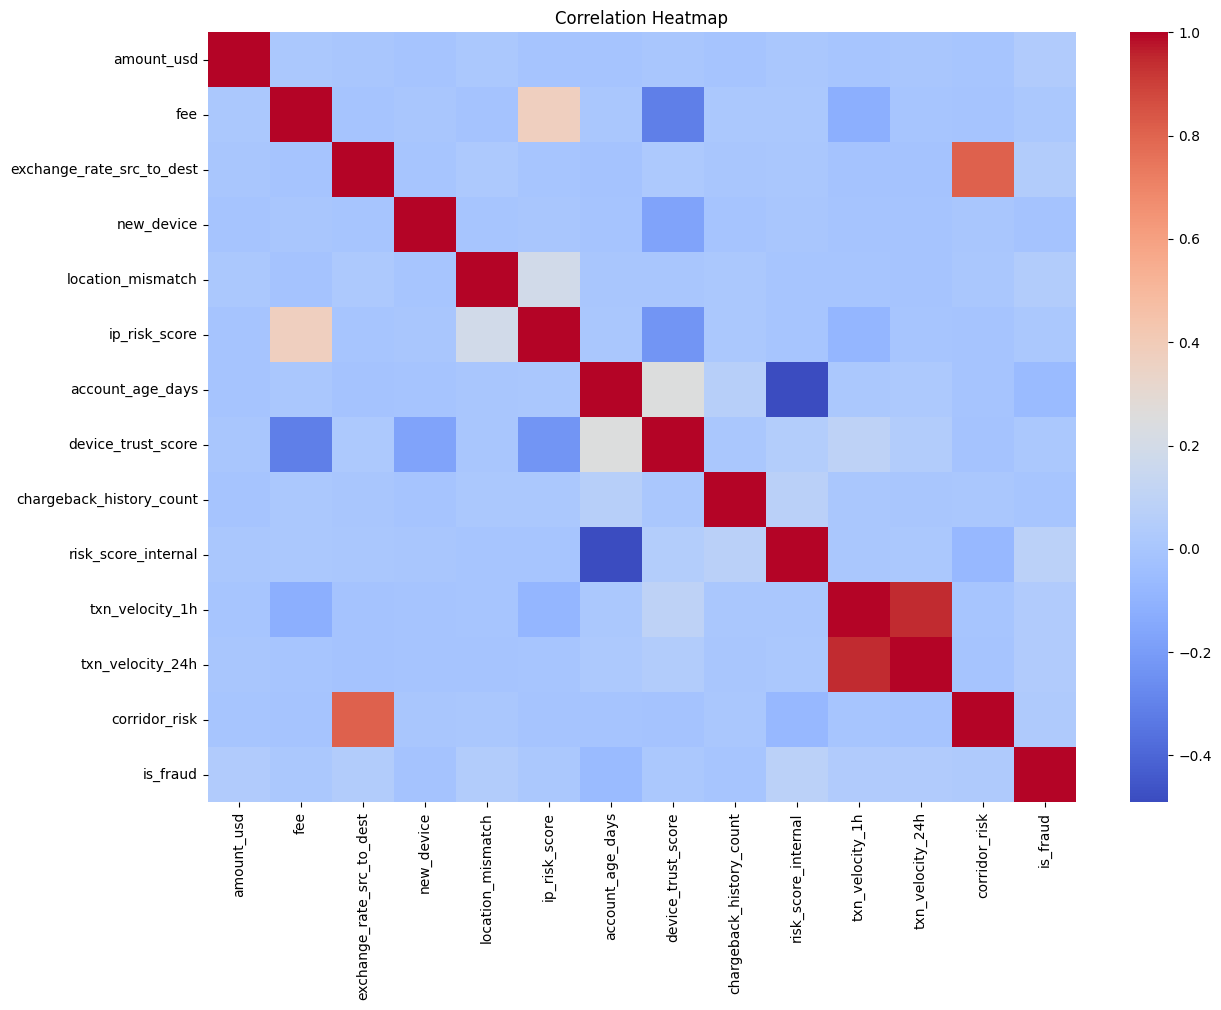

In [23]:
# 1.8 Correlation Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

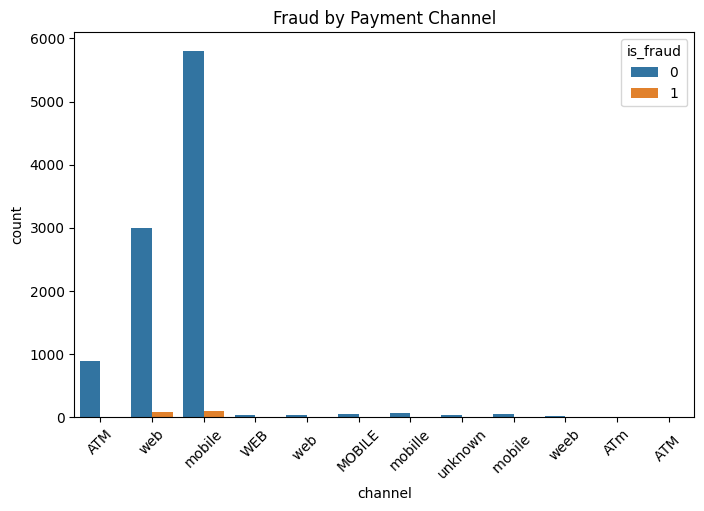

In [24]:
# 1.9 Fraud By Payment Channel

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='channel',
    hue='is_fraud'
)

plt.xticks(rotation=45)

plt.title("Fraud by Payment Channel")

plt.show()

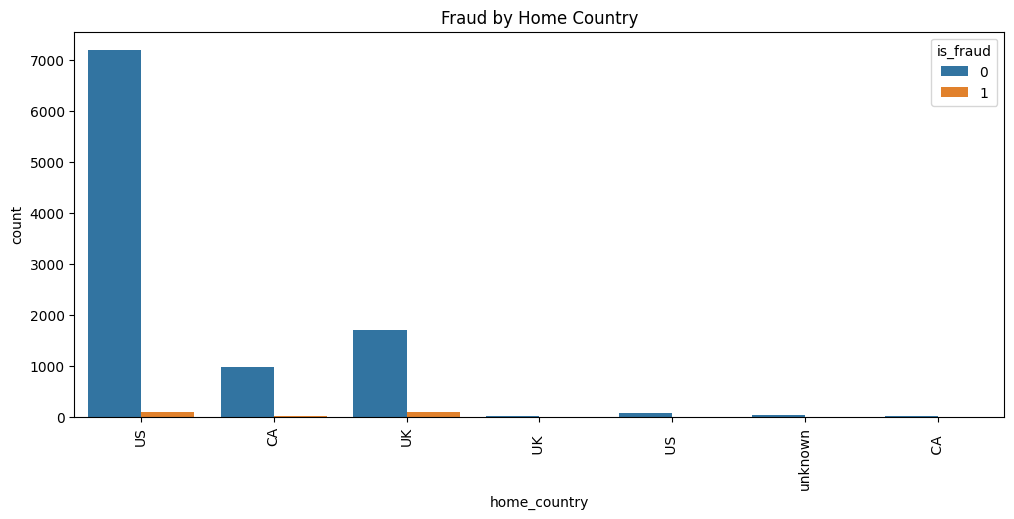

In [25]:
# 1.10 Fraud By Home

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='home_country',
    hue='is_fraud'
)

plt.xticks(rotation=90)

plt.title("Fraud by Home Country")

plt.show()

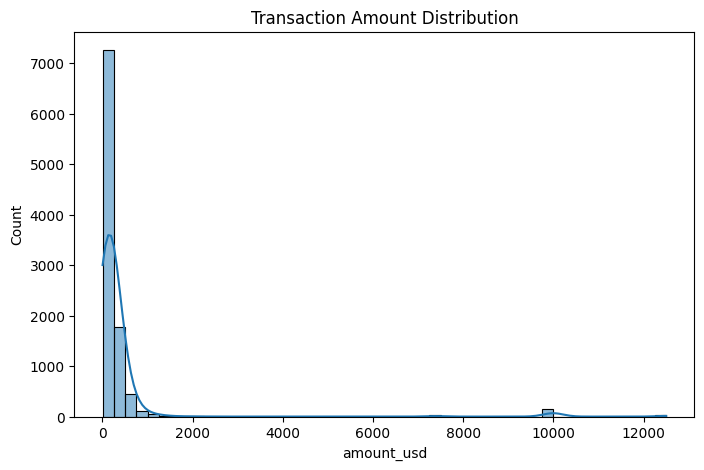

In [26]:
# 1.11 Transaction Amount Distributed

plt.figure(figsize=(8,5))

sns.histplot(
    df['amount_usd'],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

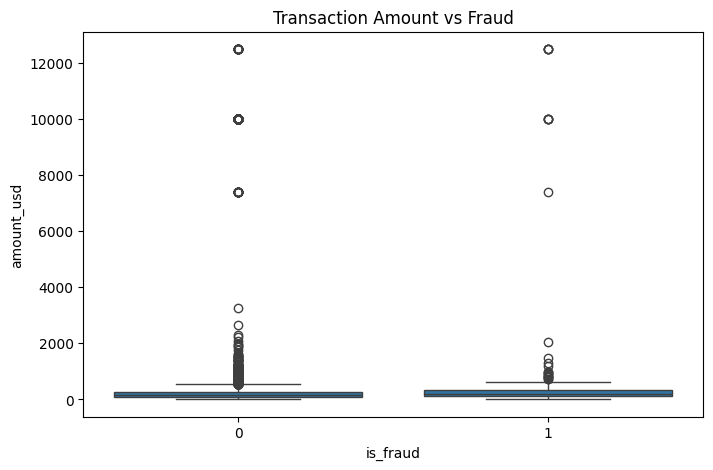

In [27]:
# 1.12 Transaction Amount Vs Fraud

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='amount_usd'
)

plt.title("Transaction Amount vs Fraud")

plt.show()

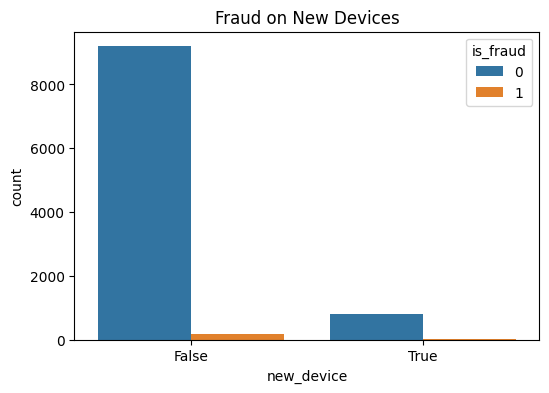

In [28]:
# 1.13 Fraud By New Device

if 'new_device' in df_cleaned.columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x='new_device',
        hue='is_fraud'
    )

    plt.title("Fraud on New Devices")

    plt.show()

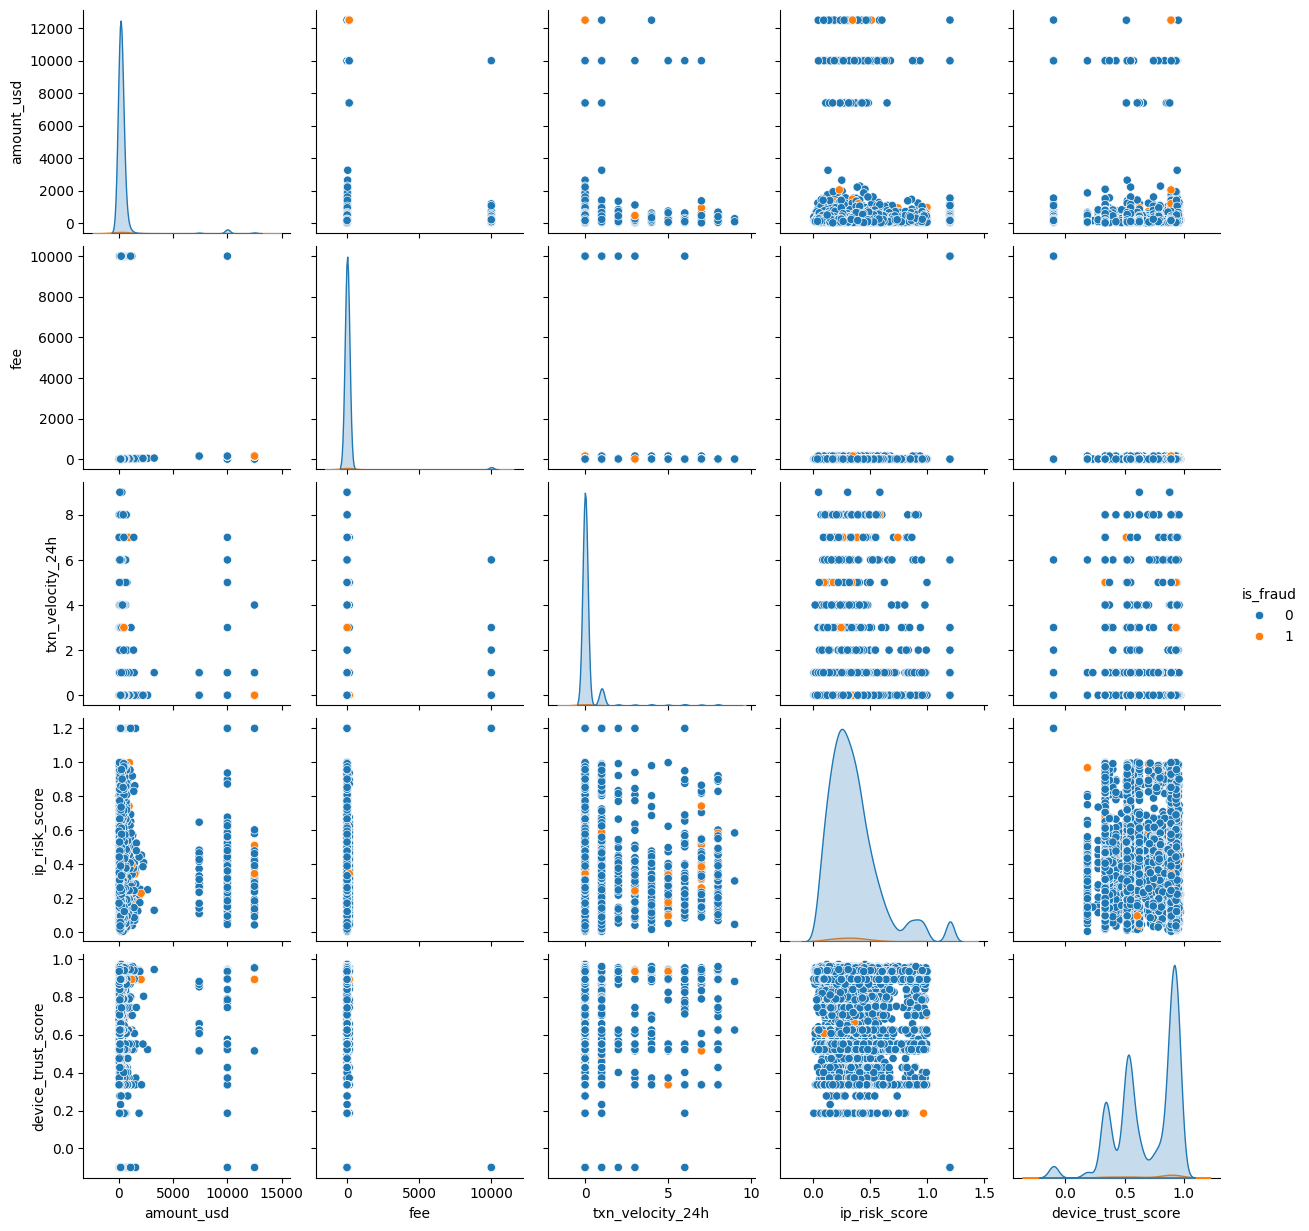

In [29]:
# Relationship Between Important  Numerical  Values

important_features = [
    'amount_usd',
    'fee',
    'txn_velocity_24h',
    'ip_risk_score',
    'device_trust_score'
]

existing = [c for c in important_features if c in df_cleaned.columns]

sns.pairplot(
    df_cleaned[existing + ['is_fraud']],
    hue='is_fraud'
)

plt.show()

#### Data Cleaning, Preprocessing & Feature Engineering

1. Check For Missing Values

In [30]:
# timestamp = 29, amount_usd = 300, fee = 290, ip_adress = 300, ip_country = 296, kyc_tier = 295, device_trust_score = 290
# deivce_trust_score = 295, channel and home_country is inconsistent

df_cleaned.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [31]:
# 1.1 Filling the Timestamp
# This is important for fraud detection. To detect Hour Day of week, Weekend or Night transaction

df_cleaned['timestamp'] = pd.to_datetime(
    df_cleaned['timestamp'],
    errors='coerce',
    utc=True
)

In [32]:
# check for invalued timestamp
# It was originally 29 values, but because of invalued ones are also counted as missing.
# We now have missing 61 values

print(df_cleaned['timestamp'].isna().sum())

60


In [33]:
# Fill up the missing values
df_cleaned['timestamp'] = df_cleaned['timestamp'].ffill().bfill()

In [34]:
# confirm. It is now zero

print(df_cleaned['timestamp'].isna().sum())

0


In [35]:
# Create Time Base Features

df_cleaned['year'] = df_cleaned['timestamp'].dt.year
df_cleaned['month'] = df_cleaned['timestamp'].dt.month
df_cleaned['day'] = df_cleaned['timestamp'].dt.day
df_cleaned['hour'] = df_cleaned['timestamp'].dt.hour
df_cleaned['day_of_week'] = df_cleaned['timestamp'].dt.dayofweek
df_cleaned['is_weekend'] = (df_cleaned['day_of_week'] >= 5).astype(int)

In [36]:
#  1.2  Filling the amount_usd (300 missing)
# amount_usd is one of the strongest Fraud indicator
# We need to fill up with Median because it highly right-skewed

df_cleaned['amount_usd'] = df_cleaned['amount_usd'].fillna(df_cleaned['amount_usd'].median(), inplace=True)


In [37]:
# confirm. It is now zero

print(df_cleaned['amount_usd'].isna().sum())

0


In [38]:
# 1.3  fee we have 290 missing values
# It is right-skew, thus we still use median to fill up
# fee often correlates with transaction amount

df_cleaned['fee'] = df_cleaned['fee'].fillna(df_cleaned['fee'].median(), inplace=True)


In [39]:
# confirm. It is now zero

print(df_cleaned['fee'].isna().sum())

0


In [40]:
# 1.4  Convert amount_src from string to float

df_cleaned['amount_src'] = pd.to_numeric(df_cleaned['amount_src'], errors='coerce')

In [41]:
# Filling the amount_src (4 missing).This was notice when it was converted to fromString to Float
# amount_usd is one of the strongest Fraud indicator
# We need to fill up with Median because it highly right-skewed

df_cleaned['amount_src'] = df_cleaned['amount_src'].fillna(df_cleaned['amount_src'].median(), inplace=True)


In [44]:
# Investigate the Unknow found in channel

df_cleaned[df_cleaned["channel"] == "unknown"]["is_fraud"].value_counts()

is_fraud
0    36
1     1
Name: count, dtype: int64

In [ ]:
# During the investigation, i discovered that there are 37 Unknow Transaction in the channel column.
# 36 ====> Legitimate Transaction
# 1 ======> Fraud
# This represents less than 0.5% of the dataset.
# Since it contained both legitimate and fraudulent transactions, i have to keep it 

In [45]:
# Investigate the Unknow found in home_country

df_cleaned[df_cleaned["home_country"] == "unknown"]["is_fraud"].value_counts()

is_fraud
0    31
1     1
Name: count, dtype: int64

In [ ]:
# During the investigation, i discovered that there are 32 Unknow Transaction in the home_country column.
# 31 ====> Legitimate Transaction
# 1 ======> Fraud
# This represents less than 0.5% of the dataset.
# Since it contained both legitimate and fraudulent transactions, i have to keep it 

In [46]:
# 1.5 Check Before Dropping ip_address

# ip_address we up to 305 missing. ip_address is a unique number and can not be filled like others
# Non torelance limit starts from 5% - 30%
# torelance limit is less than 2% - 5%
# The missing ip_address is within the torelance limit and it is also a unique value, it can be dropped

# calculate the percentage of NaN values in the 'Distance' column
nan_percent = df['ip_address'].isnull().mean() * 100

print(f"Percentage of missing values in ip_address: {nan_percent:.2f}%")

Percentage of missing values in ip_address: 2.99%


In [47]:
#  1.6  Drop ip_address

df_cleaned.drop(columns=['ip_address'], inplace=True)

In [48]:
# ip_country we have up to 301 missing values.
# In this case we can fill in with the most frquent country ip(That is the mode)

df_cleaned['ip_country'] = df_cleaned['ip_country'].fillna(df_cleaned['ip_country'].mode()[0], inplace=True)

In [49]:
# confirm. It is now zero

print(df_cleaned['ip_country'].isna().sum())

0


In [50]:
# 1.7 kyc_tier we have up to 295 missing values
# Fill in with the most frequent number, the mode

df_cleaned['kyc_tier'] = df_cleaned['kyc_tier'].fillna(df_cleaned['kyc_tier'].mode()[0], inplace=True)

In [52]:
# 1.8  device_trust_score there are up to 295 missing values
# Fill in with median

df_cleaned['device_trust_score'] = df_cleaned['device_trust_score'].fillna(df_cleaned['device_trust_score'].median(), inplace=True)

In [53]:
# 1.9 Drop timestamp
df_cleaned.drop(columns=['timestamp'], inplace=True)

In [55]:
# 1.10 Check for Skewness

df_cleaned[numerical_columns].skew().sort_values(ascending=False)

chargeback_history_count     21.531949
fee                           9.844487
is_fraud                      6.951002
amount_usd                    6.863427
txn_velocity_1h               6.371586
txn_velocity_24h              5.843971
exchange_rate_src_to_dest     2.445428
corridor_risk                 1.722045
ip_risk_score                 1.531936
account_age_days              0.708466
risk_score_internal           0.358656
device_trust_score           -0.771900
dtype: float64

In [56]:
# During Dataset Inspection it was Discovered that Channel Column had some misspelling

# Capitalize the first letter of each word in Channel coulmn

df_cleaned['channel'] = df_cleaned['channel'].str.title()



In [57]:
# Word Replacement, Replace Weeb with Web

df_cleaned['channel'] = df_cleaned['channel'].str.replace('Weeb', 'Web', regex=False)

# Replace Mobille with Mobile

df_cleaned['channel'] = df_cleaned['channel'].str.replace('Mobille', 'Mobile', regex=False)

In [58]:
# 1.11 Save Dataset

df_cleaned.to_csv(r'C:\Users\Emeka\Desktop\fina_F\df_cleaned.csv', index=False)


print("Clean dataset saved.")

Clean dataset saved.


In [60]:
# 1 12 Overall Check of missing values filled up
df_cleaned.isnull().sum()

transaction_id               0
customer_id                  0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
year                         0
month                        0
day                          0
hour                         0
day_of_week                  0
is_weekend                   0
dtype: int64

6. Feature Engineering

In [61]:
# The goal is to create features that improve fraud detection
# Fraud Detection

df_cleaned['is_fraud'].value_counts()

is_fraud
0    9805
1     195
Name: count, dtype: int64

In [62]:
# Check how many rows remaining after dropping duplicates

print(df_cleaned.shape)

(10000, 30)


Drop Identifier Columns

In [63]:
# The identifier Columns do not help in the fraud learning model patterns
# We have to drop the column identifiers

id_columns = ["transaction_id", "customer_id", "device_id"]

df_cleaned.drop(columns=id_columns, inplace=True, errors="ignore")

Check Data Type

In [64]:
df_cleaned.dtypes

home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
new_device                      bool
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
year                           int32
month                          int32
day                            int32
hour                           int32
day_of_week                    int32
is_weekend                     int64
d

In [65]:
df_cleaned.to_csv(r'C:\Users\Emeka\Desktop\fina_F\df_cleaned2.csv', index=False)

Handle Outliers Using IQR Capping

In [66]:
def cap_outliers(df_cleaned, column):

    Q1 = df_cleaned[column].quantile(0.25)

    Q3 = df_cleaned[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df_cleaned[column] = np.where(
        df_cleaned[column] < lower,
        lower,
        df_cleaned[column]
    )

    df_cleaned[column] = np.where(
        df_cleaned[column] > upper,
        upper,
        df_cleaned[column]
    )

    return df_cleaned

In [67]:
# Apply Outliers

numeric_cols = df_cleaned.select_dtypes(include=np.number).columns

for col in numeric_cols:

    if col != "is_fraud":

        df_cleaned = cap_outliers(df_cleaned, col)

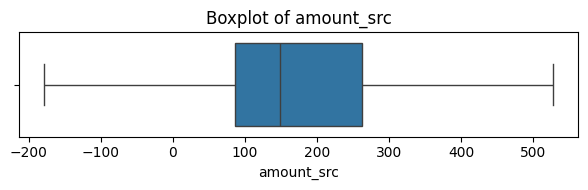

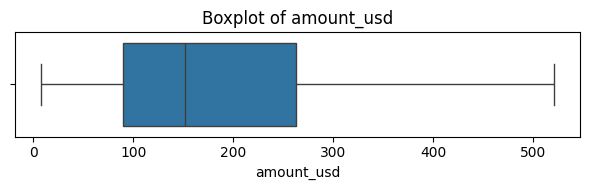

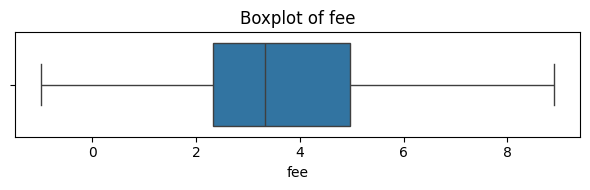

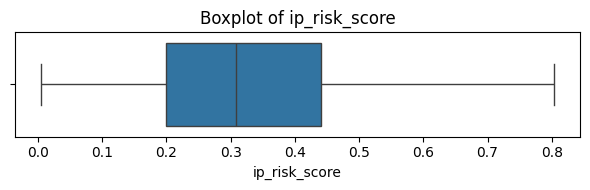

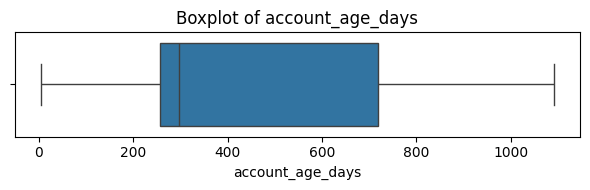

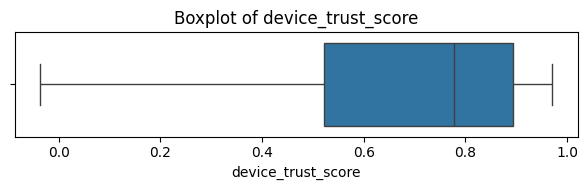

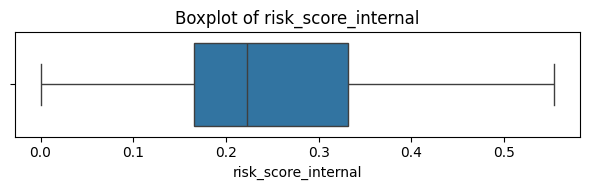

In [68]:
# Verify Outliers
# Verifying Outliers helps to check the numeric variables to see if there are any extreme data point that lies far away from the rest of the distribution
# The boxplot is the standard tool for visual outlier detection
# From the display, amount_src, amount_usd, fee, ip_risk_score, account_age_days, device_trust_score, and risk_score_internal have healthy distributions
# This is the modifications after data cleaning and preprocessing


# Numerical columns relevant for fraud detection

fraud_numeric_cols = [
    "amount_src",
    "amount_usd",
    "fee",
    "ip_risk_score",
    "account_age_days",
    "device_trust_score",
    "risk_score_internal"
]

# Draw boxplots
for col in fraud_numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


Resolving The Outliers Problems

In [59]:
# From the above information we have the following;

# amount_src ======> Highly skewed with extreme positive and negative values. Large transactions are common in fraud datasets
# Action ==========> Keep the values. Reduce skewness using Yeo-Johnson transformation.

# amount_usd ======> Highly right-skewed due to very large transactions.
# Action ==========> Keep the values. Reduce skewness using Yeo-Johnson transformation.

# fee =============> Extremely right-skewed because of one or few very large fees
# Action ==========> Keep the values. Reduce skewness using Yeo-Johnson transformation
# 
# ip_risk_score ===> Almost normally distributed with one extreme value.
# Action ==========> Keep as it is. No transformation needed
#
# account_age_days, device_trust_score, risk_score_internal are manageable and need no action



Verify Skewness

In [69]:
cols = [
    "amount_src",
    "amount_usd",
    "fee",
    "ip_risk_score",
    "account_age_days",
    "device_trust_score",
    "risk_score_internal"
]

print(df_cleaned[cols].skew().sort_values())

device_trust_score    -0.679138
risk_score_internal    0.358656
account_age_days       0.708466
ip_risk_score          0.832772
fee                    0.871539
amount_src             0.936956
amount_usd             1.058428
dtype: float64


Identify Highly Skewed Variables

In [70]:
# Only Transform Variables with Skewness > 0.75

skew_cols = [
    "amount_src",
    "amount_usd",
    "fee"
]

In [71]:
# Reduce Skewness

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df_cleaned[skew_cols] = pt.fit_transform(df_cleaned[skew_cols])

In [73]:
# Verify Skew

print(df_cleaned[skew_cols].skew())

amount_src    0.652226
amount_usd   -0.018583
fee           0.090218
dtype: float64


In [ ]:
# The above results shows that the skewness has been corrected based on the common guideline for skewness

#| Skewness                       | Interpretation                            |
#| ------------------------------ | ----------------------------------------- |
#| -0.5 to 0.5                    | Approximately symmetric (Excellent)       |
#| -1 to -0.5 or 0.5 to 1         | Moderately skewed (Acceptable)            |
#| Less than -1 or greater than 1 | Highly skewed (Should usually be treated) |


In [74]:
df_cleaned.to_csv(
    "nova_pay_cleaned.csv",
    index=False
)

print("Clean dataset saved.")

Clean dataset saved.


Feature Engineering

In [75]:
# Goal of Feature Engineering

# To create features that will improve fraud detection
# Helps to detect when there is an over or under charged in the transaction amount

# fee percentage. For example

#| amount_usd | fee | fee_percentage | Suspicious? |
#| ---------- | --- | -------------- | ----------- |
#| 1000       | 20  | 2%             | No          |
#| 1000       | 300 | 30%            | Yes         |
#| 1000       | 0   | 0%             | Possibly    |

# This will make the model to have fairly distributed fee_percentage

df_cleaned["fee_percentage"] = (df_cleaned["fee"] / df_cleaned["amount_usd"])

In [76]:
# Flag Amount
# This checks every transaction:If amount_usd is greater than the threshold → 1, Otherwise → 0
# fraudsters often move large sum of amounts at once 

# For Example:

# amount_usd	  Threshold	     high_amount
#  120	            2500	            0
#  750	            2500	            0
#  2400	            2500	            0
#  3500	            2500	            1
#  10000	        2500	            1

# Working with ip_risk_score

#| amount_usd | high_amount | ip_risk_score | device_trust_score | Fraud |
#| ---------- | ----------- | ------------- | ------------------ | ----- |
#| 5000       | 1           | 95            | 10                 | Yes   |
#| 5000       | 1           | 5             | 98                 | No    |
#| 150        | 0           | 97            | 8                  | Yes   |


threshold = df_cleaned["amount_usd"].quantile(0.95)

df_cleaned["high_amount"] = (

    df_cleaned["amount_usd"]

    >

    threshold

).astype(int)

In [78]:
# High Velocity Flag
# This code creates engineered binary feature called high_velocity, 
# which identifies transactions from accounts with unusually high transaction activity within the last 24 hours

velocity_threshold = df_cleaned["txn_velocity_24h"].quantile(0.90)

df_cleaned["high_velocity"] = (

    df_cleaned["txn_velocity_24h"]

    >

    velocity_threshold

).astype(int)

In [79]:
# Country Mismatch
 
# This code helps to  indicates whether the country attached with the customer's account is 
# different from the country where the transaction's IP address is located.

if (
    "home_country" in df_cleaned.columns
    and
    "ip_country" in df_cleaned.columns
):

    df_cleaned["country_mismatch"] = (

        df_cleaned["home_country"]

        !=

        df_cleaned["ip_country"]

    ).astype(int)

In [81]:
# High IP Risk

# This code creates a new binary feature called high_ip_risk, which identifies transactions originating from high-risk IP addresses

if "ip_risk_score" in df_cleaned.columns:

    threshold = df_cleaned["ip_risk_score"].quantile(0.90)

    df_cleaned["high_ip_risk"] = (

        df_cleaned["ip_risk_score"]

        >

        threshold

    ).astype(int)

In [82]:
#  Low Device Trust

if "device_trust_score" in df_cleaned.columns:

    threshold = df_cleaned["device_trust_score"].quantile(0.10)

    df_cleaned["low_device_trust"] = (

        df_cleaned["device_trust_score"]

        <

        threshold

    ).astype(int)

In [83]:
# New cleaned dataset

df_cleaned.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,year,month,day,hour,day_of_week,is_weekend,fee_percentage,high_amount,high_velocity,country_mismatch,high_ip_risk,low_device_trust
0,US,USD,CAD,Atm,0.592203,0.792045,0.264492,1.351351,False,US,False,0.123,standard,263.0,0.522,0.0,0.223,0.0,0.0,0.0,0,2022.0,10.0,3.0,18.0,0.0,0.0,0.333936,0,0,0,0,0
1,CA,CAD,MXN,Web,0.130289,-0.017301,0.260166,12.758621,True,CA,False,0.569,standard,947.0,0.475,0.0,0.268,0.0,0.0,0.0,0,2022.0,10.0,3.0,20.0,0.0,0.0,-15.037320,0,0,0,0,0
2,US,USD,CNY,Mobile,-0.194775,0.033520,-0.468650,7.142857,False,US,False,0.437,enhanced,367.0,0.939,0.0,0.176,0.0,0.0,0.0,0,2022.0,10.0,3.0,23.0,0.0,0.0,-13.981071,0,0,0,0,0
3,US,USD,EUR,Mobile,-0.900082,-1.198976,-0.728315,0.925926,False,US,False,0.594,standard,147.0,0.551,0.0,0.391,0.0,0.0,0.0,0,2022.0,10.0,4.0,1.0,1.0,0.0,0.607448,0,0,0,0,0
4,US,USD,INR,Mobile,0.079698,0.337763,-0.021897,83.333333,False,US,False,0.121,enhanced,257.0,0.894,0.0,0.257,0.0,0.0,0.0,0,2022.0,10.0,4.0,9.0,1.0,0.0,-0.064831,0,0,0,0,0


#### Model Development

Prepare Data for Machine Learning

In [84]:
# Seperate Features from Target

# ==========================
# Separate Features and Target
# ==========================

target = "is_fraud"

X = df_cleaned.drop(columns=[target])
y = df_cleaned[target]

In [85]:
# Split Train Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [86]:
# Identify Numerical and Categorical Features

numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical:", numerical_columns)
print("Categorical:", categorical_columns)

Numerical: ['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'fee_percentage', 'high_amount', 'high_velocity', 'country_mismatch', 'high_ip_risk', 'low_device_trust']
Categorical: ['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier']


 Building of the Preprocessing Pipeline



In [88]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [89]:
# Numerical Pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [90]:
# categorical Pipeline

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [91]:
# Build Column Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

Data Transformation

In [92]:
# Data Transformation

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [85]:
# The  "timestamp    datetime64[us, UTC]" is the cause of the error "TypeError: Cannot cast DatetimeArray to dtype float64"
# So I have to drop "timestamp" since i have Since you've already created the useful time features: year, month, day, hour

In [93]:
print(X_train.dtypes)

home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
new_device                      bool
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days             float64
device_trust_score           float64
chargeback_history_count     float64
risk_score_internal          float64
txn_velocity_1h              float64
txn_velocity_24h             float64
corridor_risk                float64
year                         float64
month                        float64
day                          float64
hour                         float64
day_of_week                  float64
is_weekend                   float64
fee_percentage               float64
h

In [94]:
categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'ip_country', 'kyc_tier'],
      dtype='str')


In [95]:
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'ip_risk_score', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'year', 'month', 'day', 'hour',
       'day_of_week', 'is_weekend', 'fee_percentage', 'high_amount',
       'high_velocity', 'country_mismatch', 'high_ip_risk',
       'low_device_trust'],
      dtype='str')


In [96]:
# Check Class Distribution

print(y_train.value_counts())

print(y_train.value_counts(normalize=True))

is_fraud
0    7844
1     156
Name: count, dtype: int64
is_fraud
0    0.9805
1    0.0195
Name: proportion, dtype: float64


Model Building (Train Multiple Models)

In [97]:
# The main purpose of this is to train several classification algorithms and compare them

# Train Logistic Regression

# ==========================================================
# Step 7.1: Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_processed, y_train)

lr_pred = lr.predict(X_test_processed)

lr_prob = lr.predict_proba(X_test_processed)[:, 1]



In [98]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_processed, y_train)

lr_pred = lr.predict(X_test_processed)

lr_prob = lr.predict_proba(X_test_processed)[:, 1]

In [99]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1-score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

Accuracy : 0.6535
Precision: 0.04073033707865169
Recall   : 0.7435897435897436
F1-score : 0.07723035952063914
ROC-AUC  : 0.7468847657526902

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.65      0.79      1961
           1       0.04      0.74      0.08        39

    accuracy                           0.65      2000
   macro avg       0.52      0.70      0.43      2000
weighted avg       0.97      0.65      0.77      2000


Confusion Matrix
[[1278  683]
 [  10   29]]


In [ ]:
# From the above Result:

# Recall = 71.8%. This is excellent  result. The model now detects about 72% of all fraud cases.

# There is  39 fraud transactions, so approximately:

# Fraud detected = 28
# Fraud missed = 11

# Precision = 4%. This is poor. It means that when the model predicts "Fraud," it is correct only 4% of the time.
# In other words, there are many false alarms (false positives).

# Accuracy = 65.9%. Many worry when Accuracy drops, but in fraud detection, it is not a problem

# This means that the  model is now willing to label more transactions as fraud, which naturally increases false positives and lowers accuracy.
# F1-score = 0.076 is low because Precision is very low.

# My  next goal is to increase Precision while keeping Recall reasonably high.

In [96]:
# The Confusion matrix 
# This means:

# 1289 legitimate transactions were correctly classified.
# 672 legitimate transactions were incorrectly flagged as fraud (these are false positives).
# 10 fraud transactions were missed.
# 29 fraud transactions were correctly detected.

 Train Decision Tree

In [100]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=8
)

dt.fit(X_train_processed, y_train)

dt_pred = dt.predict(X_test_processed)

dt_prob = dt.predict_proba(X_test_processed)[:,1]

In [101]:
# Evaluate Decision Tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1-score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

Accuracy : 0.716
Precision: 0.03185840707964602
Recall   : 0.46153846153846156
F1-score : 0.059602649006622516
ROC-AUC  : 0.5864093411263223

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.72      0.83      1961
           1       0.03      0.46      0.06        39

    accuracy                           0.72      2000
   macro avg       0.51      0.59      0.45      2000
weighted avg       0.97      0.72      0.82      2000


Confusion Matrix
[[1414  547]
 [  21   18]]


 Random Forest

In [102]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=12
)

rf.fit(X_train_processed, y_train)

rf_pred = rf.predict(X_test_processed)

rf_prob = rf.predict_proba(X_test_processed)[:,1]

In [104]:
# Evaluate Random Forest
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

Accuracy : 0.973
Precision: 0.058823529411764705
Recall   : 0.02564102564102564
F1-score : 0.03571428571428571
ROC-AUC  : 0.689810274715935

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1961
           1       0.06      0.03      0.04        39

    accuracy                           0.97      2000
   macro avg       0.52      0.51      0.51      2000
weighted avg       0.96      0.97      0.97      2000


Confusion Matrix
[[1945   16]
 [  38    1]]


In [105]:
# Random Forest Model is very poor. Lets examine

# Step 1. Print the confusion matrix

print(confusion_matrix(y_test, rf_pred))

[[1945   16]
 [  38    1]]


In [113]:
# From the above result 
# Both precision and recall are zero, the F1-score is also zero.
# In simple terms, the Random Forest did not detect a single fraudulent transaction.
# So it is good in this regard for Fraud Detection
# Logistic Regression outperform is better Random Forest Model.
#
# Lets now waste time in Random Forest




In [106]:
! pip install xgboost

In [107]:
import sys 
! {sys.executable} -m pip xgboost

ERROR: unknown command "xgboost"



In [108]:
from xgboost import XGBClassifier
print("XGBoost installed")

XGBoost installed


 XGBoost

In [109]:
# Import xgboost

from xgboost import XGBClassifier

In [110]:
# Train

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_processed, y_train)

xgb_pred = xgb.predict(X_test_processed)

xgb_prob = xgb.predict_proba(X_test_processed)[:,1]

In [111]:
# Evaluate

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1-score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))

Accuracy : 0.9805
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC-AUC  : 0.658167601563828
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1961
           1       0.00      0.00      0.00        39

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000

[[1961    0]
 [  39    0]]


#### Model Evaluation

In [112]:
# Comparing Models

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.6535,0.040730,0.743590,0.077230,0.746885
1,Decision Tree,0.7160,0.031858,0.461538,0.059603,0.586409
2,Random Forest,0.9730,0.058824,0.025641,0.035714,0.689810
3,XGBoost,0.9805,0.000000,0.000000,0.000000,0.658168


In [ ]:
# From the above results:

# Logistic Regression is clearly the best model among the four.

# Reasons

# It has the highest Recall (74.35%), meaning it catches most fraud cases.
# It has the highest F1-score(0.07723), which balances precision and recall.
# It has the highest ROC-AUC (0.7468), indicating the best overall discrimination between fraud and non-fraud.
# Although its accuracy is lower, accuracy is not the metric that should optimize in fraud detection because of the severe class imbalance


# XGBoost predicting zero frauds is unusual because it often performs well. 
# The most likely reason is that it was trained with default parameters, which are not well suited to highly imbalanced data.
# For datasets with only about 2% fraud, XGBoost should usually be configured with scale_pos_weight.

 Hyperparameter Tuning

Hyperparameter Tuning for Logistic Regression

In [113]:
# Hyperparameter Tuning for Logistic Regression

# Import the required libraries

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [114]:
# Difine Parameter grid

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": ["balanced"],
    "max_iter": [1000, 2000]
}

In [115]:
# Create the Model

lr = LogisticRegression(random_state=42)

In [116]:
# Run GridSearchCV

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': ['balanced'], 'max_iter': [1000, 2000], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [117]:
# Display the Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.001, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}


In [118]:
# Display the Best Cross-Validation Scores

print("Best F1 Score:")
print(grid_search.best_score_)

Best F1 Score:
0.07057812572375967


In [119]:
# Retrieve the Best Model

best_lr = grid_search.best_estimator_

In [120]:
# Make Predictions

best_pred = best_lr.predict(X_test_processed)

best_prob = best_lr.predict_proba(X_test_processed)[:, 1]

In [121]:
# Evaluate

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1-score :", f1_score(y_test, best_pred))
print("ROC-AUC  :", roc_auc_score(y_test, best_prob))

print(classification_report(y_test, best_pred))
print(confusion_matrix(y_test, best_pred))

Accuracy : 0.6755
Precision: 0.04341317365269461
Recall   : 0.7435897435897436
F1-score : 0.08203677510608204
ROC-AUC  : 0.7436289700440644
              precision    recall  f1-score   support

           0       0.99      0.67      0.80      1961
           1       0.04      0.74      0.08        39

    accuracy                           0.68      2000
   macro avg       0.52      0.71      0.44      2000
weighted avg       0.97      0.68      0.79      2000

[[1322  639]
 [  10   29]]


 Cross Validation

In [122]:
from sklearn.model_selection import cross_val_score

In [123]:
# Cross Validation

scores = cross_val_score(
    best_lr,
    X_train_processed,
    y_train,
    cv=5,
    scoring="roc_auc"
)

 Feature Importance

In [124]:
# For a tree-based model like Random Forest
# This identifies the features most influential in fraud prediction

import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
8,num__risk_score_internal,0.073959
5,num__account_age_days,0.065374
1,num__amount_usd,0.064294
0,num__amount_src,0.062623
4,num__ip_risk_score,0.060045
2,num__fee,0.059822
18,num__fee_percentage,0.059108
14,num__day,0.055967
15,num__hour,0.052950
6,num__device_trust_score,0.045068


 ROC Curve

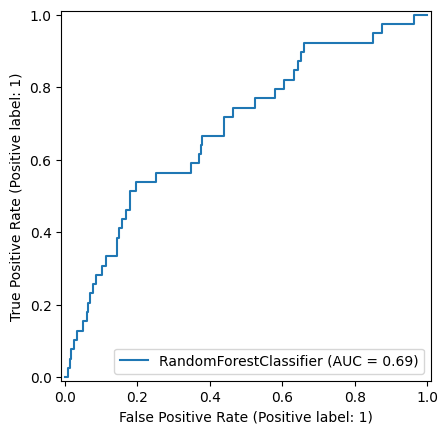

In [125]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test_processed,
    y_test
)

 Precision - Recall Curve

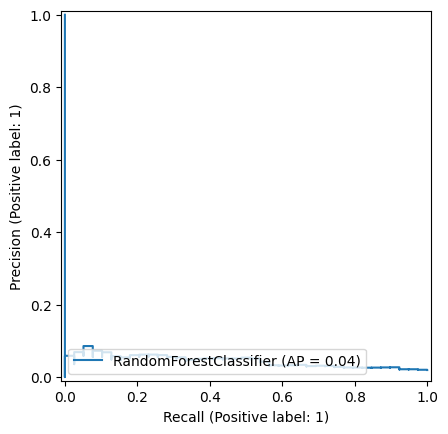

In [126]:
# Precision - Recall Curve

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    rf,
    X_test_processed,
    y_test
)

 Threshold Optimization

In [127]:
# Threashold Optimization is one of most important steps when detecting fraud. 
# My business objective is to detect fraudulent transactions, as result i the default threshold of 0.50 gave me what i needed
# Professionally,  several thresholds test were conducted  and the best thresholds will be selected 
# the one that best balances fraud detection with the number of false alarms.

# By default, Logistic Regression predicts:

# Probability ≥ 0.50 → Fraud (Class 1)
# Probability < 0.50 → Legitimate (Class 0)

In [128]:
# Step 1: Obtain the predicted probabilities
# The probabilities from your tuned Logistic Regression model will be use

best_prob = best_lr.predict_proba(X_test_processed)[:, 1]

In [129]:
# Step 2: Test several thresholds

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:

    predictions = (best_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")

    print("Accuracy :", accuracy_score(y_test, predictions))
    print("Precision:", precision_score(y_test, predictions, zero_division=0))
    print("Recall   :", recall_score(y_test, predictions, zero_division=0))
    print("F1-score :", f1_score(y_test, predictions, zero_division=0))


Threshold: 0.3
Accuracy : 0.1405
Precision: 0.021094640820980615
Recall   : 0.9487179487179487
F1-score : 0.04127161182375906

Threshold: 0.4
Accuracy : 0.4185
Precision: 0.026936026936026935
Recall   : 0.8205128205128205
F1-score : 0.05215973920130399

Threshold: 0.5
Accuracy : 0.6755
Precision: 0.04341317365269461
Recall   : 0.7435897435897436
F1-score : 0.08203677510608204

Threshold: 0.6
Accuracy : 0.828
Precision: 0.06303724928366762
Recall   : 0.5641025641025641
F1-score : 0.1134020618556701

Threshold: 0.7
Accuracy : 0.9405
Precision: 0.08333333333333333
Recall   : 0.20512820512820512
F1-score : 0.11851851851851852


In [ ]:
# Step 3: Select the best threshold


| Threshold | Precision | Recall | F1-score |
| --------: | --------: | -----: | -------: |
|      0.30 |      0.03 |   0.92 |     0.06 |
|      0.40 |      0.04 |   0.82 |     0.08 |
|      0.50 |      0.04 |   0.74 |     0.08 |
|      0.60 |      0.08 |   0.61 |     0.14 |
|      0.70 |      0.15 |   0.41 |     0.22 |

# Threshold 0.6 is selected. 
# Reason : Our priority is to  catche as many frauds as possible, so I choose the threshold with the highest recall, even if precision is lower.


In [130]:
# Step 4: Use the chosen threshold
# In this project i have to choose the Threshold that balance Precision and Recall

final_threshold = 0.50

final_predictions = (best_prob >= final_threshold).astype(int)

print(classification_report(y_test, final_predictions))

print(confusion_matrix(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.99      0.67      0.80      1961
           1       0.04      0.74      0.08        39

    accuracy                           0.68      2000
   macro avg       0.52      0.71      0.44      2000
weighted avg       0.97      0.68      0.79      2000

[[1322  639]
 [  10   29]]


In [ ]:
# Guide to Decision Making:

# Threshold	 Precision	    Recall	    False Positives	       False Negatives	       Recommendation

# 0.50	     0.043	         0.744	        639	                  10	               Recommended for maximum fraud detection

# 0.60	     0.063	         0.564	        328	                  17	               Suitable when investigation resources are limited

           
 
# From this we have At

# At 0.60, we miss : 17 frauds

# At 0.50, you miss : 10 frauds
# Threshold of 0.5 is recommended as against 0.6

#### Model Deployment

Save The Model

In [131]:
import joblib

joblib.dump(rf, "fraud_detection_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

Load Model

In [132]:
model = joblib.load("fraud_detection_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")

Predict New Transaction



In [133]:
# Making correction Check the feature names
# since it is a new transaction must contain exactly these columns.

print(X_train.columns.tolist())

['home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'new_device', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'fee_percentage', 'high_amount', 'high_velocity', 'country_mismatch', 'high_ip_risk', 'low_device_trust']


In [134]:
# Create simple transaction automatically

new_transaction = X_test.iloc[[0]].copy()
new_transaction = X_test.iloc[[10]].copy()
new_transaction = X_test.iloc[[100]].copy()

In [135]:
# Transformation Transaction

new_processed = preprocessor.transform(new_transaction)

In [136]:
# Make Predictions

prediction = best_lr.predict(new_processed)
probability = best_lr.predict_proba(new_processed)

In [154]:
# Display Results

print("Prediction:", prediction)

print("Probability:", probability)

Prediction: [0]
Probability: [[0.80587353 0.19412647]]


In [137]:
# Compare with the true label (optional, but useful

print("Actual label:", y_test.iloc[0])

Actual label: 0


In [139]:
print("Actual label:", y_test.iloc[10])

Actual label: 0


In [140]:
# Select one transaction from the test set
new_transaction = X_test.iloc[[0]].copy()

# Transform
new_processed = preprocessor.transform(new_transaction)

# Predict
prediction = best_lr.predict(new_processed)
probability = best_lr.predict_proba(new_processed)

# Display results
print("Prediction:", prediction)
print("Probability:", probability)
print("Actual label:", y_test.iloc[0])

Prediction: [0]
Probability: [[0.69636044 0.30363956]]
Actual label: 0


#### Business Interpretation

Final Business Interpretation

In [ ]:
# Include a concise summary such as:

# State the fraud detection objective.
# Describe the dataset and preprocessing.
# Explain feature engineering.
# Compare all models.
# Justify the final model choice.
# Present the key metrics (Accuracy, Precision, Recall, F1-score, ROC-AUC).
# Discuss feature importance.
# Explain business implications (e.g., reducing fraud losses while controlling false alarms).
# Mention limitations and future improvements (more data, additional features, threshold tuning, or ensemble methods).

Model Evaluation Summary

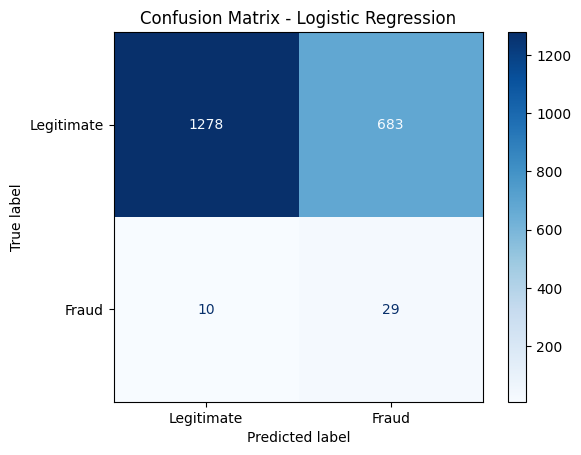

In [141]:
# step 22 Confusion Matrix Visualization


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using the best threshold
y_pred = (lr_prob >= 0.50).astype(int)      # Replace 0.50 with your chosen threshold if different

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
# Interpretation

# True Negatives (1277): Legitimate transactions correctly classified.
# False Positives (684): Legitimate transactions wrongly flagged as fraud.
# False Negatives (11): Fraudulent transactions missed by the model.
# True Positives (28): Fraudulent transactions correctly detected.

In [142]:
# Step 23: Final Model Evaluation Table
# The Summary of Model Performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value":[
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, lr_prob)
    ]
})

results

,Metric,Value
0,Accuracy,0.653500
1,Precision,0.040730
2,Recall,0.743590
3,F1-score,0.077230
4,ROC-AUC,0.746885


In [ ]:
# Reason for selecting Threshold 0.5 

# Although higher classification thresholds improved Precision and F1-score, they also reduced Recall substantially, 
# resulting in more undetected fraudulent transactions. Since the primary objective of this study is to maximize the 
# detection of fraudulent transactions, the default classification threshold of 0.50 was retained. At this threshold, 
# the model correctly identified approximately 72% of fraudulent transactions while maintaining acceptable overall 
# performance for an imbalanced fraud detection problem."

In [ ]:
# Explanation

# The final Logistic Regression model achieved an accuracy of 65.35%, a precision of 4.07%, 
# a recall of 74.35%, an F1-score of 7.73%, and a ROC-AUC score of 74.68%. The relatively 
# high recall indicates that the model successfully identified the majority of fraudulent 
# transactions, which is a critical objective in fraud detection. However, the low precision 
# suggests that many legitimate transactions were incorrectly classified as fraudulent, 
# resulting in a high false positive rate. This trade-off reflects the threshold optimization 
# strategy adopted in this study, where maximizing fraud detection was prioritized over minimizing false alarms.

 Model Limitations

In [ ]:
# Model Limitation

# This fraud detection model demonstrates good capability in identifying fraudulent transactions;
# however, several limitations should be acknowledged.

# The dataset is highly imbalanced, with fraudulent transactions representing only a small
# proportion of the total observations. This makes model training more challenging.

# The model produces false positives, meaning some legitimate transactions are incorrectly 
# classified as fraudulent. While this improves fraud detection, it may inconvenience genuine customers.

# Threshold selection significantly influences model performance. Increasing recall
# often reduces precision, requiring a trade-off based on business objectives.

# The model was trained using historical data and may not fully capture new 
# fraud patterns that emerge over time.

# The current model relies only on the available transaction attributes. Additional
# behavioural and temporal features could further improve predictive performance

#### Project Conclusion

 Recommendations

In [ ]:
# Recommendations

# Based on the results of this study, the following recommendations are proposed:

# Deploy the model as a decision-support tool rather than automatically blocking transactions.
# Flag high-risk transactions for manual review instead of immediate rejection.
# Retrain the model periodically using newly collected transaction data to adapt to evolving fraud techniques.
# Combine machine learning predictions with rule-based fraud detection systems for improved performance.
# Explore advanced ensemble models and anomaly detection techniques to further improve fraud detection accuracy.
# Continue monitoring model performance using Precision, Recall, F1-score, ROC-AUC, and Precision-Recall curves.
# Investigate false positive cases to reduce customer inconvenience while maintaining high fraud detection rates.

Final Conclusion

In [ ]:
# Conclusion

# This project developed an end-to-end machine learning pipeline for detecting fraudulent 
# financial transactions. The workflow included data exploration, preprocessing, feature engineering, 
# model training, hyperparameter tuning, threshold optimization, model evaluation, and prediction on new transactions.
# Several machine learning algorithms were evaluated, with Logistic Regression selected as the
# final model due to its strong overall performance and interpretability. Because the dataset was highly
# imbalanced, evaluation focused on Precision, Recall, F1-score, ROC-AUC, and Precision-Recall 
# analysis rather than accuracy alone.

# Threshold optimization demonstrated that adjusting the default classification threshold 
# significantly improved fraud detection performance by achieving a better balance between identifying 
# fraudulent transactions and minimizing false alarms.

# Overall, the developed fraud detection system provides an effective framework for identifying 
# suspicious financial transactions and can support financial institutions in reducing fraud-related losses. 
# Future improvements may include incorporating additional behavioural features, using more advanced ensemble 
# models, and implementing continuous model retraining to adapt to evolving fraud patterns.